In [2]:
library(shazam)

db <- read.table(
  "/Users/catg/Desktop/SOFIAC/Gitsofia/tesisbioinf-sofia/data/output/repertorio_D_insilico_100_seqs_db-pass.tsv",
  header = TRUE,
  sep = "\t"
)

dist <- distToNearest(
  db,
  sequenceColumn = "junction",
  vCallColumn = "v_call",
  jCallColumn = "j_call",
  model = "ham",
  normalize = "len"
)$dist_nearest

dist <- dist[!is.na(dist)]

out <- findThreshold(dist, method = "density")

out@threshold

Warning message:
"replacing previous import 'S4Arrays::makeNindexFromArrayViewport' by 'DelayedArray::makeNindexFromArrayViewport' when loading 'SummarizedExperiment'"


To cite the SHazaM package in publications, please use:

  Gupta N, Vander Heiden J, Uduman M, Gadala-Maria D, Yaari G,
  Kleinstein S (2015). "Change-O: a toolkit for analyzing large-scale B
  cell immunoglobulin repertoire sequencing data." _Bioinformatics_,
  1-3. doi:10.1093/bioinformatics/btv359
  <https://doi.org/10.1093/bioinformatics/btv359>.

To cite the selection analysis methods, please use:

  Yaari G, Uduman M, Kleinstein S (2012). "Quantifying selection in
  high-throughput Immunoglobulin sequencing data sets." _Nucleic acids
  research_, *40*(17), e134. doi:10.1093/nar/gks457
  <https://doi.org/10.1093/nar/gks457>.

To cite the HH_S5F model and the targeting model generation methods,
please use:

  Yaari G, Vander Heiden J, Uduman M, Gadala-Maria D, Gupta N, Stern J,
  O'Connor K, Hafler D, Lasserson U, 

[1] NA

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 0.1538  0.2821  0.2889  0.3142  0.3556  0.4524 

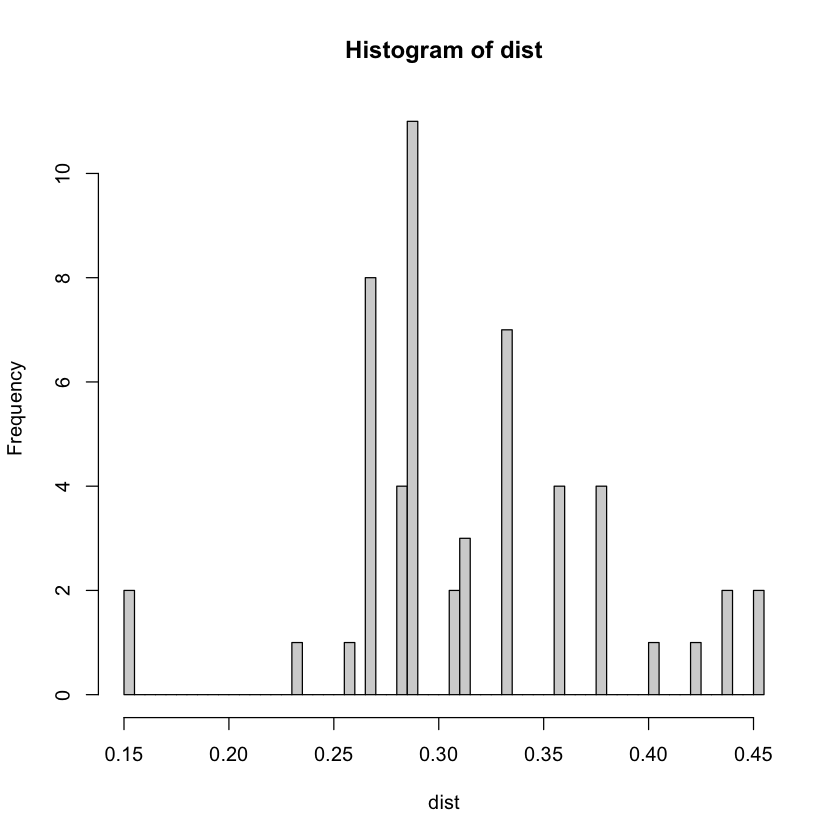

In [3]:
hist(dist, breaks = 50)
summary(dist)

Warning message:
"Removed 2 rows containing missing values or values outside the scale range
(`geom_bar()`)."
Warning message:
"Removed 1 row containing missing values or values outside the scale range
(`geom_vline()`)."


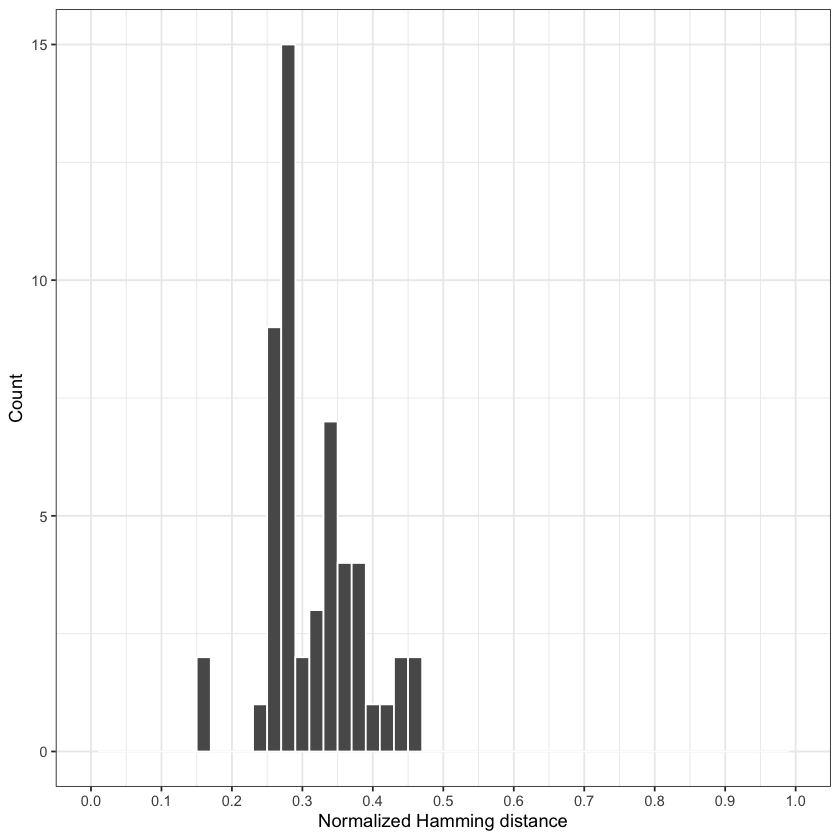

In [4]:
library(ggplot2)

threshold <- out@threshold

p1 <- ggplot(data.frame(dist = dist), aes(x = dist)) +
  geom_histogram(
    color = "white",
    binwidth = 0.02
  ) +
  geom_vline(
    xintercept = threshold,
    color = "firebrick",
    linetype = 2
  ) +
  labs(
    x = "Normalized Hamming distance",
    y = "Count"
  ) +
  scale_x_continuous(
    breaks = seq(0, 1, 0.1),
    limits = c(0, 1)
  ) +
  theme_bw()

p1